In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [5]:
#Satır Numarası,Müşteri Kimliği,Soyadı,Kredi Puanı,Coğrafya(ülke),Cinsiyet,Yaş,Kıdem,Bakiye,Ürün Sayısı,Kredi Kartı Var mı,Aktif Üye mi,
#Tahmini Maaş,Ayrıldı(bu son sütun classification yapacağımız target columnu amacı da müşteri bankayı bırakacak mı bırakmayacak mı?)

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.shape

(10000, 14)

In [10]:
df["Geography"].nunique()

3

In [11]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [12]:
df.drop(["RowNumber","CustomerId","Surname"],axis=1,inplace=True)

In [13]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [14]:
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


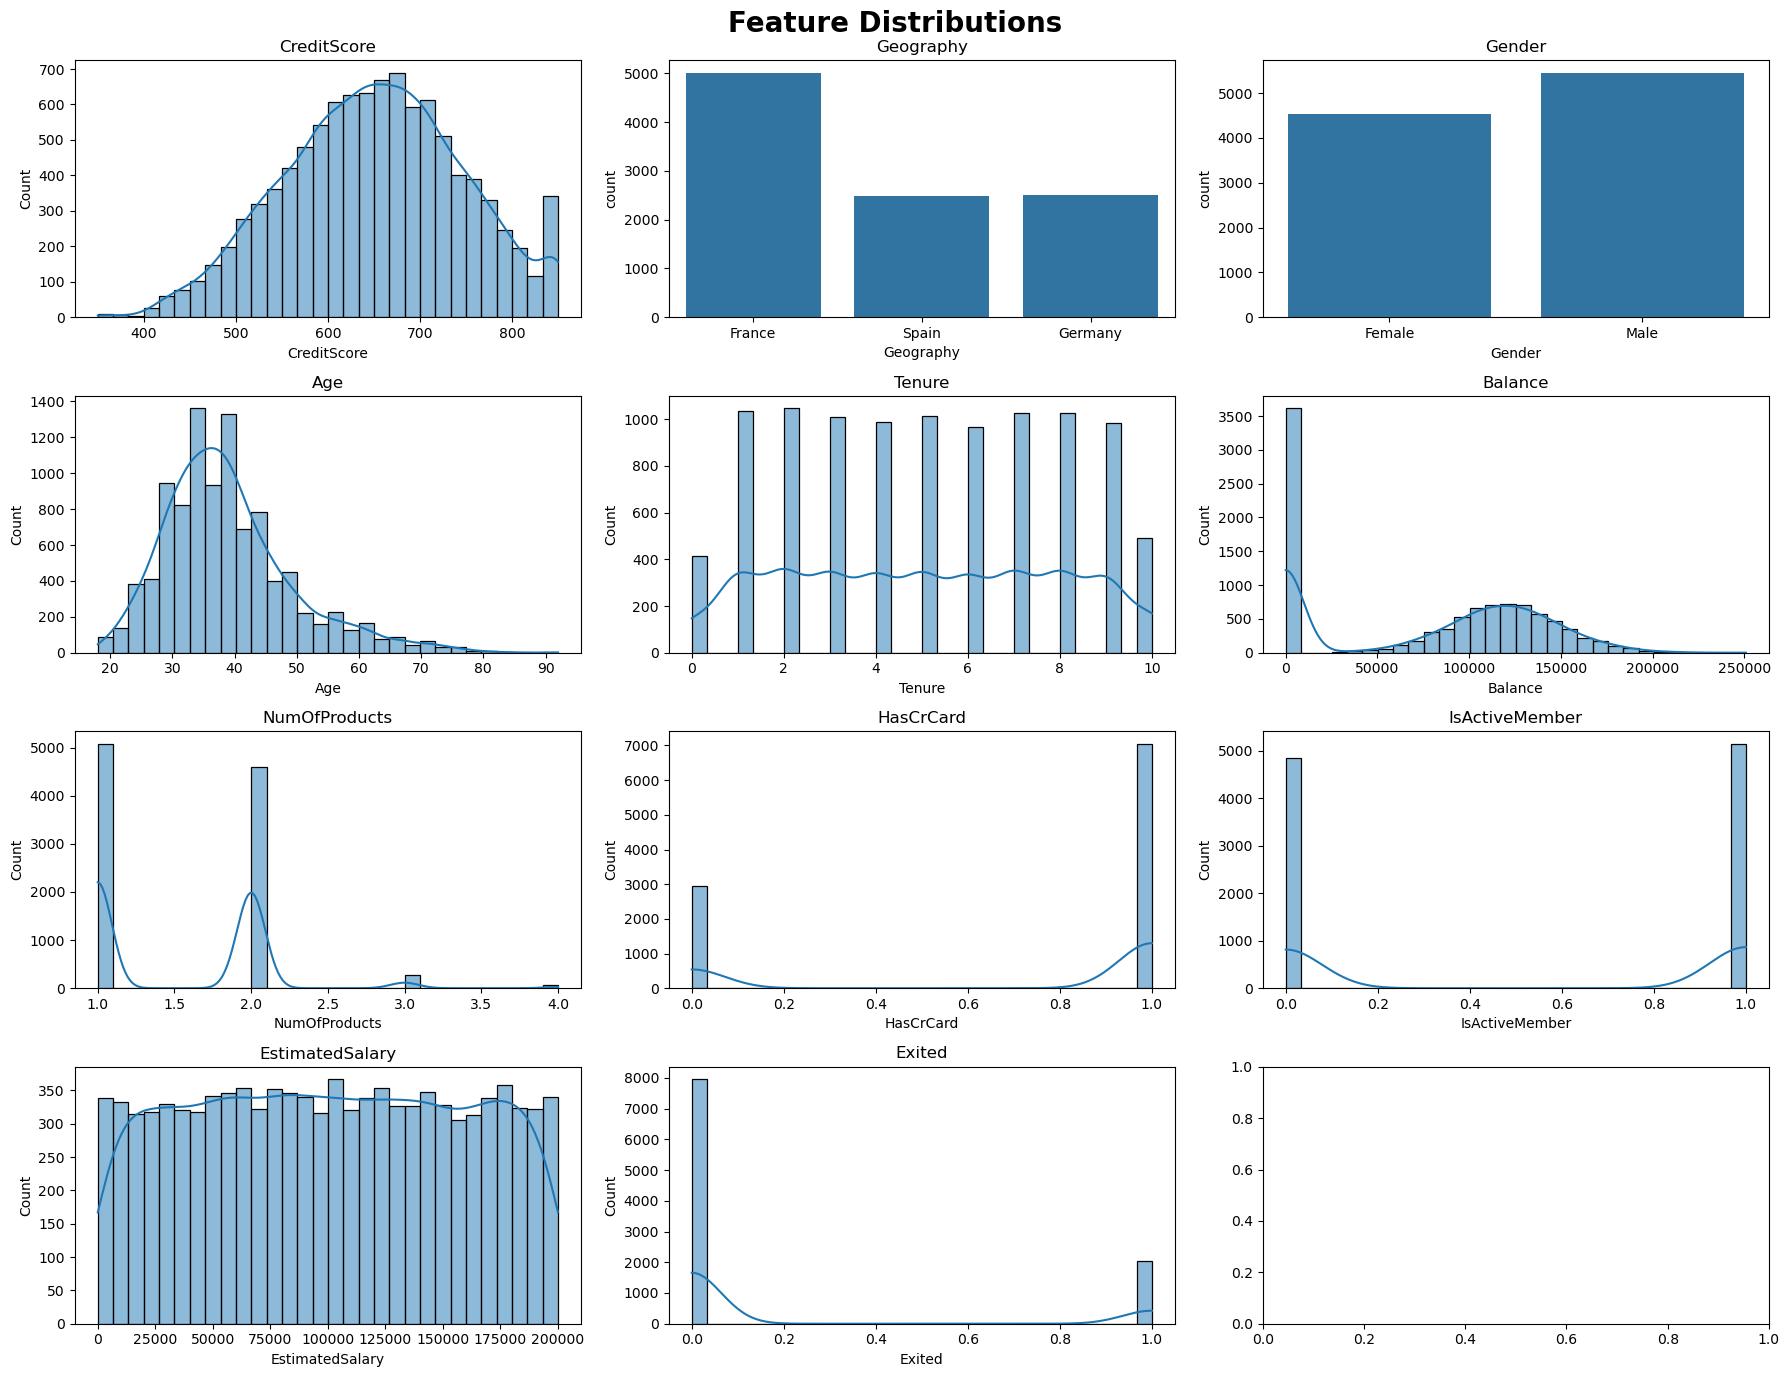

In [15]:
columns = [
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'Exited'
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18,14)
)

fig.suptitle(
    "Feature Distributions",
    fontsize=20,
    fontweight="bold"
)

for i, feature in enumerate(columns):

    row = i // 3
    col = i % 3

    ax = axes[row, col]

    if df[feature].dtype == "object":

        sns.countplot(
            data=df,
            x=feature,
            ax=ax
        )

    else:

        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            bins=30,
            ax=ax
        )

    ax.set_title(feature)

plt.tight_layout()

plt.show()


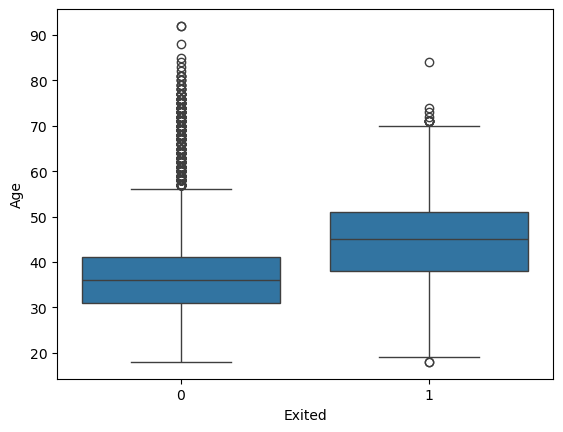

In [16]:
sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)
plt.show()

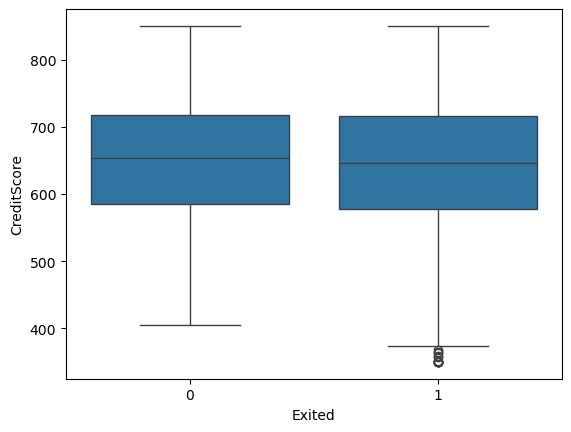

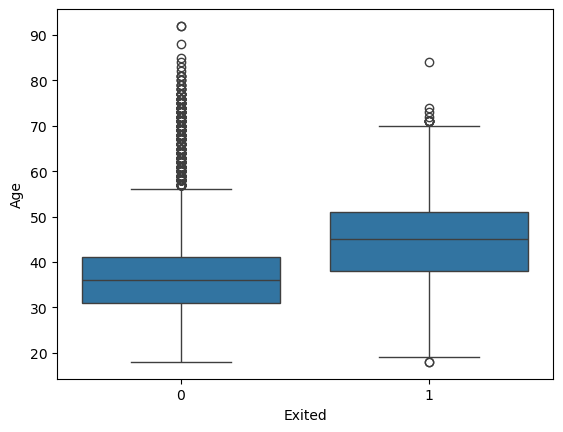

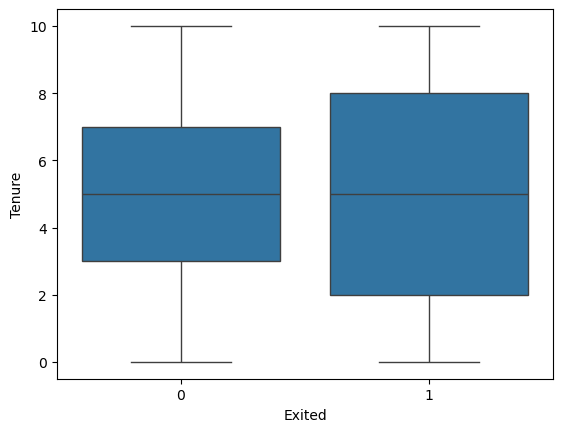

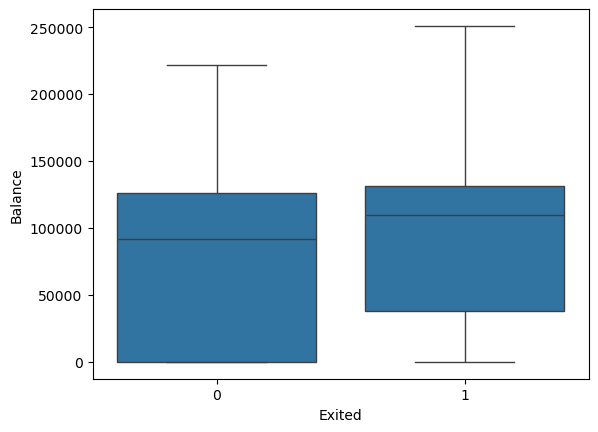

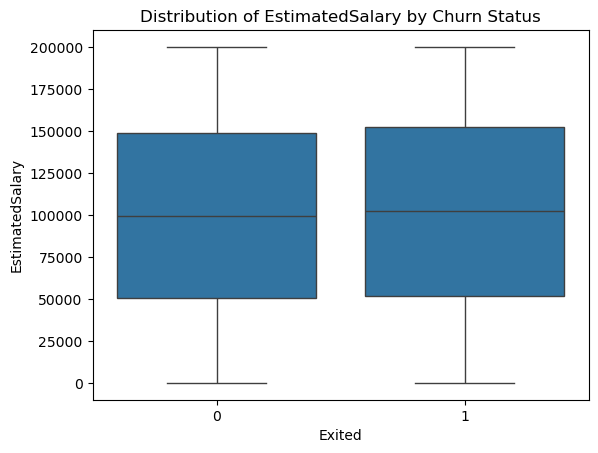

In [17]:
numerical_cols=[    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"]
for col in numerical_cols:
    plt.figure()
    sns.boxplot(
    data=df,
    x="Exited",
    y=col
)
plt.title(f"Distribution of {col} by Churn Status")
plt.show()


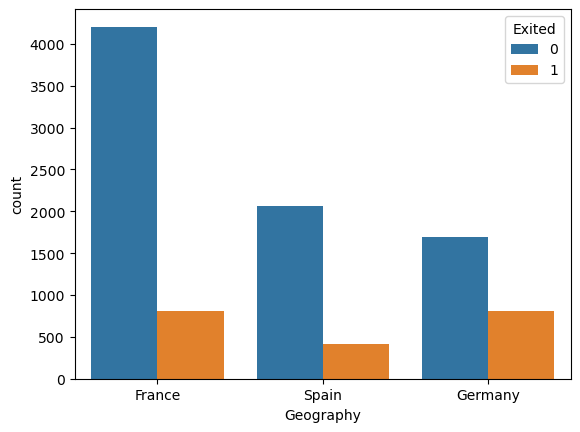

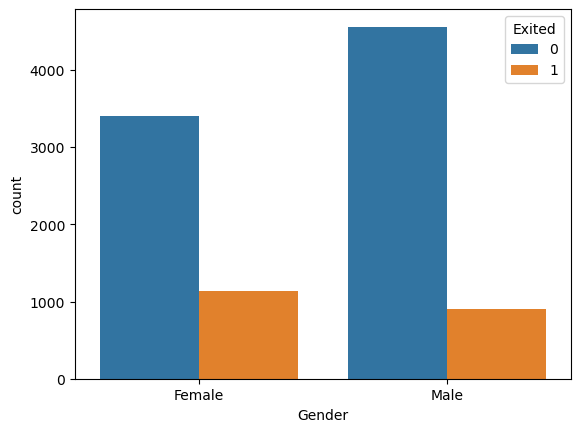

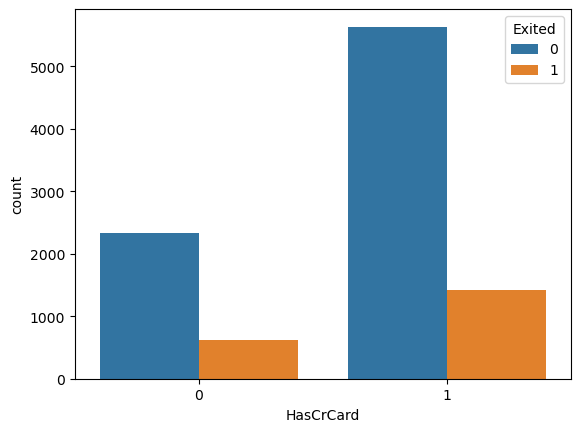

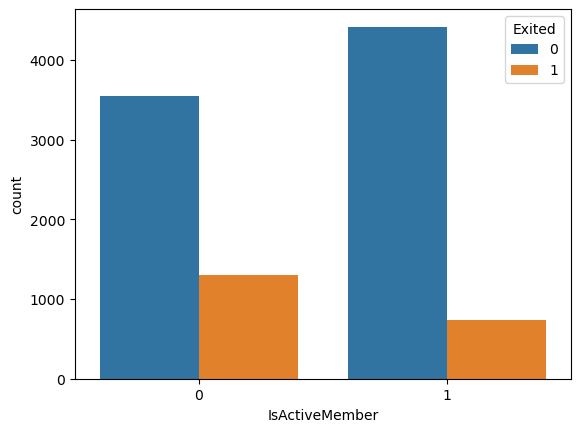

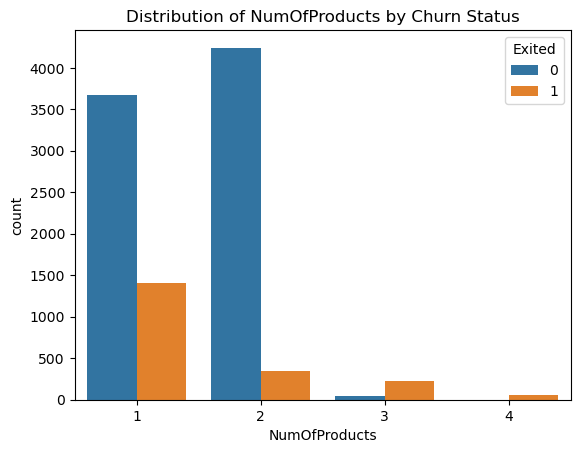

In [18]:
categorical_cols=[
    "Geography",
    "Gender",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts"]
for col in categorical_cols:
    plt.figure()
    sns.countplot(
    data=df,
    hue="Exited",
    x=col
)
plt.title(f"Distribution of {col} by Churn Status")
plt.show()


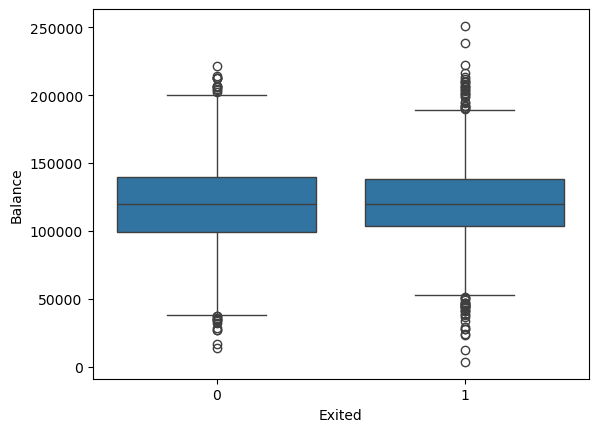

In [19]:
#Customers with higher account balances appear more likely to churn compared to customers with zero balances.
sns.boxplot(
    data=df[df["Balance"]>0],
    x="Exited",
    y="Balance"
)
plt.show()

In [20]:
num_cols=[    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary",
    "Exited"]

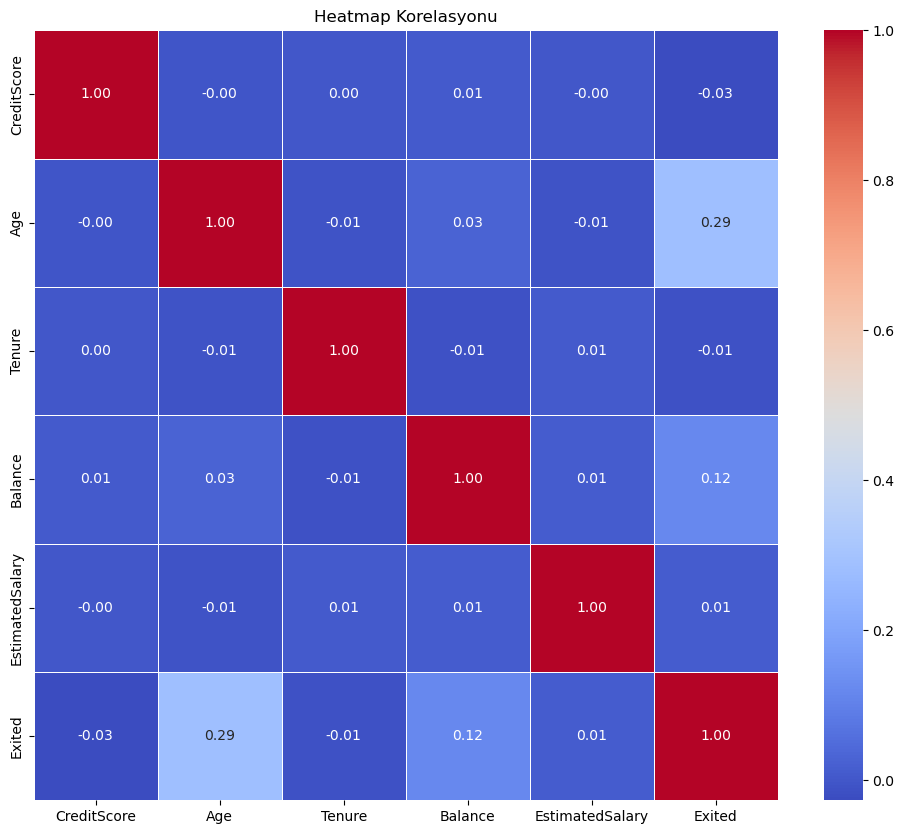

In [21]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasyonu')
plt.show()

In [22]:
df.duplicated().sum()

0

In [23]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    #Kodun "tüm datasetlere uygulanabilir" olmasını sağlayan yer burasıdır.
    #Tablodaki metinleri (string/object) atlar ve sadece sayısal (int/float) sütunları listeler.
    
    for col in numerical_cols:
        #Kodun kalbi olan bu yöntem, veriyi küçükten büyüğe dizer ve 4 parçaya böler.
        #Q1 (%25'lik Dilim): Verinin ilk çeyreği.
        #Q3 (%75'lik Dilim): Verinin üçüncü çeyreği.
        #IQR: Bu iki değerin arasındaki farktır ($IQR = Q3 - Q1$).
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        #Burada "güvenli bölge" oluşturulur. Genellikle threshold (eşik) 1.5 olarak alınır.
        #Lower Bound: Alt sınır. Bunun altındakiler çok küçük uç değerlerdir.
        #Upper Bound: Üst sınır. Bunun üstündekiler çok büyük uç değerlerdir.
        

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        #altında ve üstünde kalanları outliers değişkenine ata.
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
        #outlier_count: Kaç tane aykırı değer var?
        #outlier_percentage: Verinin yüzde kaçı aykırı? (Eğer %10'dan fazlaysa veride bir sorun olabilir).
        #Sınırlar: Hangi sayıdan sonrası "aykırı" kabul edildi?
    return pd.DataFrame(outlier_summary)


In [24]:
find_outliers_iqr(df, threshold = 1.5)

,CreditScore,Age,Tenure,Balance,EstimatedSalary
outlier_count,15.00,359.00,0.0,0.00,0.00000
outlier_percentage,0.15,3.59,0.0,0.00,0.00000
lower_bound,383.00,14.00,-3.0,-191466.36,-96577.09625
upper_bound,919.00,62.00,13.0,319110.60,296967.45375


In [25]:
X=df.drop("Exited",axis=1)
y=df["Exited"]

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X_train["Gender"]=le.fit_transform(X_train["Gender"])
X_test["Gender"]=le.transform(X_test["Gender"])

In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(
    transformers=[
        ("onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            ["Geography"]
        )
    ],
    remainder="passthrough"
)

In [29]:
X_train_enc=transformer.fit_transform(X_train)
X_test_enc=transformer.transform(X_test)

In [30]:
encoded_cols = transformer.get_feature_names_out()

In [31]:
X_train=pd.DataFrame(X_train_enc,columns=encoded_cols)
X_test=pd.DataFrame(X_test_enc,columns=encoded_cols)

In [32]:
X_train.head()

,onehot__Geography_Germany,onehot__Geography_Spain,remainder__CreditScore,remainder__Gender,remainder__Age,remainder__Tenure,remainder__Balance,remainder__NumOfProducts,remainder__HasCrCard,remainder__IsActiveMember,remainder__EstimatedSalary
0,0.0,0.0,686.0,1.0,32.0,6.0,0.00,2.0,1.0,1.0,179093.26
1,1.0,0.0,632.0,1.0,42.0,4.0,119624.60,2.0,1.0,1.0,195978.86
2,0.0,1.0,559.0,1.0,24.0,3.0,114739.92,1.0,1.0,0.0,85891.02
3,0.0,0.0,561.0,0.0,27.0,9.0,135637.00,1.0,1.0,0.0,153080.40
4,0.0,0.0,517.0,1.0,56.0,9.0,142147.32,1.0,0.0,0.0,39488.04


In [33]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(    
    random_state=42,
    max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [36]:
score

0.8115

In [37]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1544,   63],
       [ 314,   79]], dtype=int64)

In [38]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier


models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42),
    "KNN":
        KNeighborsClassifier(),
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42),

    "Gradient Boost":
        GradientBoostingClassifier(
            random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42)
}

In [40]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score)


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )


    y_pred = model.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    recall = recall_score(
        y_test,
        y_pred
    )


    f1 = f1_score(
        y_test,
        y_pred
    )


    print(name)

    print(
        "Accuracy:",
        round(accuracy,3)
    )

    print(
        "Recall:",
        round(recall,3)
    )

    print(
        "F1:",
        round(f1,3)
    )

    print("-"*40)

Logistic Regression
Accuracy: 0.811
Recall: 0.201
F1: 0.295
----------------------------------------
KNN
Accuracy: 0.834
Recall: 0.392
F1: 0.48
----------------------------------------
Decision Tree
Accuracy: 0.785
Recall: 0.501
F1: 0.478
----------------------------------------
Random Forest
Accuracy: 0.872
Recall: 0.489
F1: 0.6
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost
Accuracy: 0.858
Recall: 0.489
F1: 0.574
----------------------------------------
Gradient Boost
Accuracy: 0.868
Recall: 0.489
F1: 0.592
----------------------------------------
XGBoost
Accuracy: 0.87
Recall: 0.555
F1: 0.626
----------------------------------------


In [41]:
from xgboost import XGBClassifier
xgbclassifier=XGBClassifier()

In [42]:
xgbclassifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [43]:
y_pred=xgbclassifier.predict(X_test)

In [44]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1521  175]
 [  86  218]]
accuracy score:  0.8695
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1696
           1       0.55      0.72      0.63       304

    accuracy                           0.87      2000
   macro avg       0.75      0.81      0.77      2000
weighted avg       0.89      0.87      0.88      2000



In [45]:
params = {
        "n_estimators" : [100, 200, 300, 500],
        "learning_rate" : [0.01, 0.05,0.1],
        "max_depth" : [3,5,8,12,20,30],
        "subsample":[0.8,1],
        "colsample_bytree" : [0.3, 0.4, 0.5, 0.8, 1]
}

In [46]:
from sklearn.model_selection import GridSearchCV

In [52]:
grid=GridSearchCV(estimator=xgbclassifier,param_grid=params,cv=5,n_jobs=-1,scoring="f1")

In [54]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300, 500],
                         'subsample': [0.8, 1]},
             scoring='f1')

In [55]:
grid.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 200,
 'subsample': 0.8}

In [56]:
y_pred=grid.predict(X_test)

In [57]:
print("confusion matrix: \n",confusion_matrix(y_pred,y_test))
print("accuracy score: \n",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

confusion matrix: 
 [[1534  196]
 [  73  197]]
accuracy score: 
 0.8655
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1730
           1       0.50      0.73      0.59       270

    accuracy                           0.87      2000
   macro avg       0.73      0.81      0.76      2000
weighted avg       0.89      0.87      0.88      2000



In [58]:
#Bir sıkıntı yok, tam tersine daha sağlıklı bir model elde etmişsin.
#Makine öğrenmesinde her zaman en yüksek Accuracy en iyi model demek değildi

In [61]:
model_prob=grid.predict_proba(X_test)

In [65]:
model_prob=model_prob[:,1]

In [87]:
custom_threshold=0.35

In [88]:
y_pred_custom=(
    model_prob>=custom_threshold
).astype(int)

In [89]:
print(classification_report(y_test,y_pred_custom))
#önceden 100 churn müşterisinden 55 ini yakalarken şimdi 64 ünü yakalayabiliyoruz.

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1607
           1       0.64      0.64      0.64       393

    accuracy                           0.86      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.86      0.86      0.86      2000



In [90]:
#PR Curve neye bakıyor?“Daha fazla churn müşterisi yakalamaya çalışırken ne kadar yanlış alarm veriyoruz?”
from sklearn.metrics import ( precision_recall_curve, average_precision_score)
precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        model_prob
    )
)

In [92]:
ap_score = average_precision_score(
    y_test,
    model_prob
)
print(
    "Average Precision:",
    ap_score
)

Average Precision: 0.7082979650308232


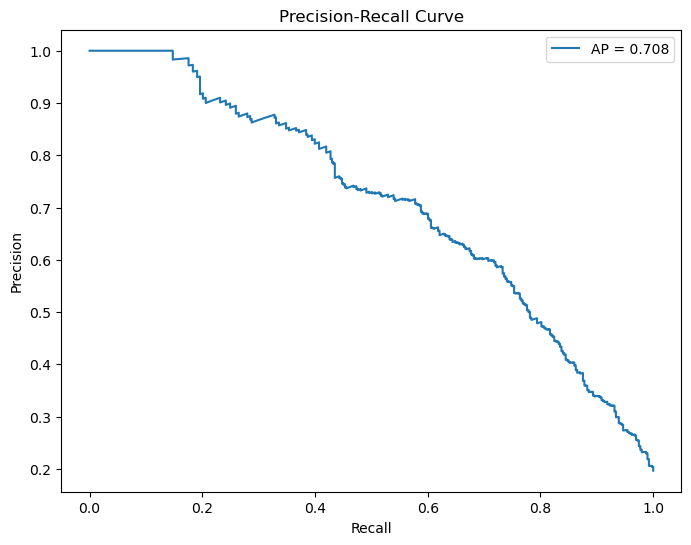

In [93]:
plt.figure(
    figsize=(8,6)
)
plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.3f}"
)
plt.xlabel(
    "Recall"
)
plt.ylabel(
    "Precision"
)
plt.title(
    "Precision-Recall Curve"
)
plt.legend()
plt.show()

In [60]:
from sklearn.metrics import roc_curve,roc_auc_score

In [66]:
model_fpr,model_tpr,thresholds=roc_curve(y_test,model_prob)

In [67]:
auc_score=roc_auc_score(y_test,model_prob)

In [68]:
auc_score

0.8710903790826077

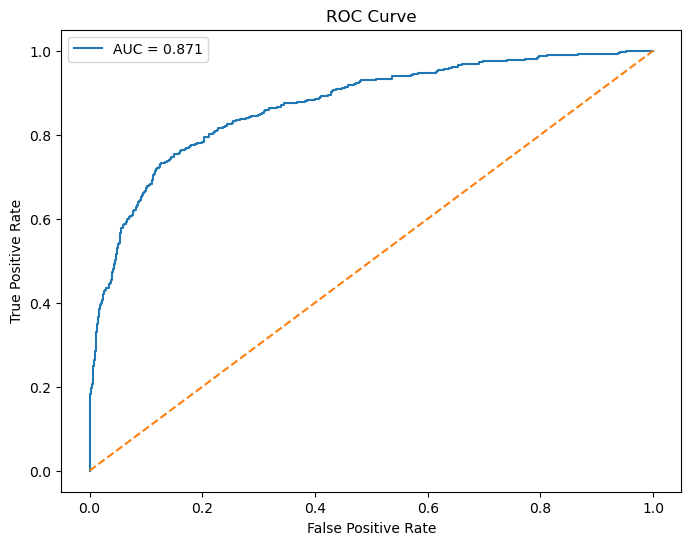

In [69]:
plt.figure(figsize=(8,6))

plt.plot(
    model_fpr,
    model_tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [83]:
feature_names = transformer.get_feature_names_out()
importance=grid.best_estimator_.feature_importances_
feature_importance=pd.DataFrame(
    {
        "feature":feature_names,
        "importance":importance
    }
)
feature_importance=feature_importance.sort_values(
    by="importance",
    ascending=False
)
feature_importance["feature"] = feature_importance["feature"].str.replace("remainder__", "", regex=False)
feature_importance["feature"] = feature_importance["feature"].str.replace("onehot__Geography_", "Geography_", regex=False)

In [84]:
feature_importance.head(10)

,feature,importance
7,NumOfProducts,0.239911
9,IsActiveMember,0.226518
4,Age,0.169281
0,Geography_Germany,0.102940
3,Gender,0.072915
6,Balance,0.051706
2,CreditScore,0.028729
5,Tenure,0.028540
1,Geography_Spain,0.027553
10,EstimatedSalary,0.027302


In [85]:
feature_importance["feature"].value_counts()

feature
NumOfProducts        1
IsActiveMember       1
Age                  1
Geography_Germany    1
Gender               1
Balance              1
CreditScore          1
Tenure               1
Geography_Spain      1
EstimatedSalary      1
HasCrCard            1
Name: count, dtype: int64

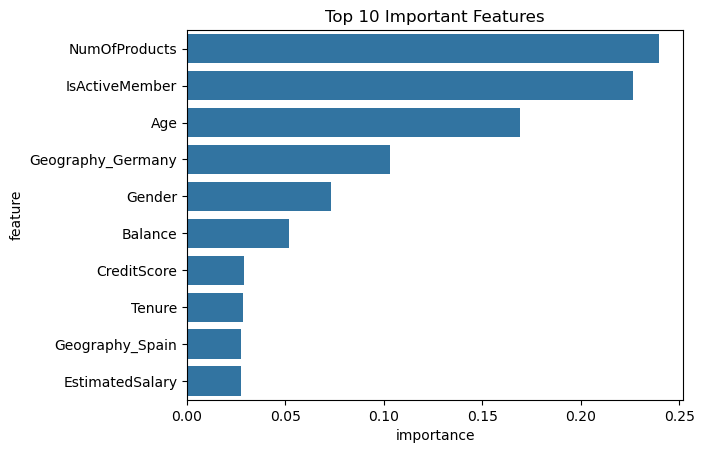

In [86]:
sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Important Features")
plt.show()

In [98]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [100]:
X_train = pd.DataFrame(

    X_train,

    columns=feature_names
)

In [101]:
X_test = pd.DataFrame(

    X_test,

    columns=feature_names
)

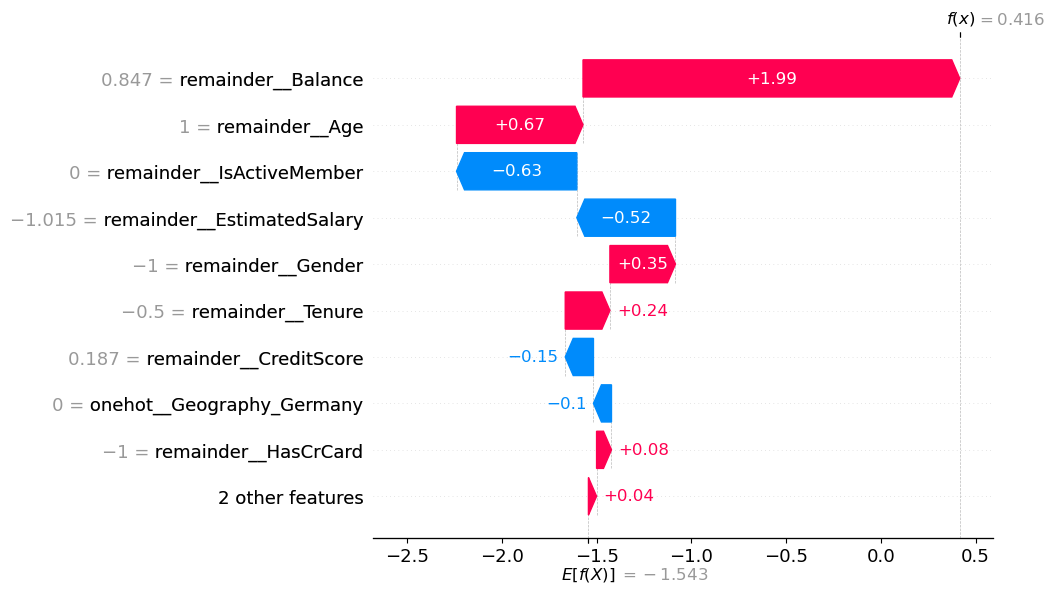

In [103]:
import shap
explainer = shap.TreeExplainer(model)
shap.waterfall_plot(
    explainer(
        X_test[25:26]
    )[0]
)

In [105]:
shap_values = explainer(
    X_test
)

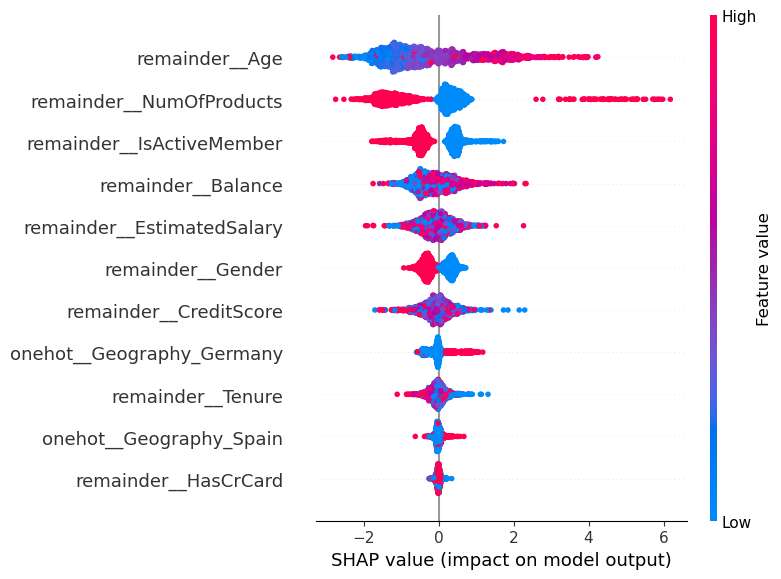

In [106]:
shap.summary_plot(
    shap_values,
    X_test
)